# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студентки гр. 2383 Щёголева Надежда и Семененко Анна. Вариант №28

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

*Ранжированный ряд* – это упорядоченные по возрастанию (или
убыванию) элементы выборки.

*Вариационный ряд* – упорядоченные элементы выборки с указанием
частоты их появления.

Формула Стерджесса для поиска оптимального количества интервалов:

$$k = 1 + 3.322 \lg(N)$$

N - объем выборки

k - оптимальное кол-во интервалов

Полученное значение округляется до целого. Рекомендуется выбирать нечетное количесвто интервалов.

Ширина интервала:

$$h = \frac{x_{\max} - x_{\min}}{k}$$

Границы интервалов:
$$[x_{\min} + (i-1)h; \, x_{\min} + ih), \quad i = 1, 2, \ldots, k-1$$
*i* - номер интервала

Последний интервал:
$$[x_{\min} + (k-1)h; \, x_{\min} + kh] $$

Эмпирическая функция распределения:

$$F^*(\tilde{x}_i) = \frac{m_i^{\text{нак}}}{N}; \quad m_i^{\text{нак}} = \sum_{j=1}^{i-1} m_j; \quad i = 1, 2, \ldots, k+1$$



## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

1. Для выполнения практической работы был выбран язык Python с библиотеками pandas и Matplotlib. Pandas обеспечивает удобное формирование и преобразование статистических рядов, а Matplotlib — визуализацию полигона, гистограммы и эмпирической функции распределения.


2. Данные о пингвинах: https://www.kaggle.com/code/sharondivinenitasha/penguins-dataset-similar-to-iris-dataset

3. Из генеральной совокупности (данные о пингвинах) была сформирована выборка объёмом 117 наблюдений путем выделения особей с острова Biscoe по признакам длины и глубины клюва. Сформированная выборка сохранена в файл penguins.csv:


In [ ]:
'''
df = df_p[(df_p["island"] == "Biscoe" )][["culmen_length_mm", "culmen_depth_mm"]]
df.head(117).to_csv("penguins.csv", index=False)
'''
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np

N = 117
df = pd.read_csv("penguins.csv")
df.head()

,culmen_length_mm,culmen_depth_mm
0,37.8,18.3
1,37.7,18.7
2,35.9,19.2
3,38.2,18.1
4,38.8,17.2


4. Преобразование выборки в ранжированный, вариационный и интервальный ряды.

In [ ]:
# количство интервалов k
k = 1 + 3.31* math.log(N, 10)
k = int(k)
k

7

In [ ]:
def rows(column):
    print(f"\nРяды для признака {column}")

    print("Ранжированный:")
    ranked_row = df[[column]].sort_values(column)
    display(ranked_row.head(10))

    print("\nВариационный:")
    variation_series = ranked_row.value_counts().sort_index().to_frame()
    display(variation_series.head(10))

    print("\nИнтервальный:")
    interval_series = [[] for _ in range(k)]
    interval = [] # численные середины  интервалов (для отрисовки гистограмм)
    data_rows = [] # для вывода в виде таблицы
    max_x = ranked_row[column].max() # x_max
    min_x = ranked_row[column].min() # x_min
    h = (max_x - min_x)/k

    # [x_min + (i-1) * h; x_min + i * h), i = 1, 2,..., k-1
    for i in range(0, k-1):
      min = min_x + i * h
      max = min_x + (i+1) * h
      interval.append((min + max)/2)
      for value, row in variation_series.iterrows():
        value = float(value[0])
        if value >= min and value < max:
          interval_series[i].append((value, int(row.iloc[0])))

    # [x_min + (k-1) * h; x_min + k * h]
    min = min_x + (k-1) * h
    max = min_x + k * h
    interval.append((min + max)/2)
    for value, row in variation_series.iterrows():
        value = float(value[0])
        if value >= min and value <= max:
          interval_series[k-1].append((value, int(row.iloc[0])))

    m_ac_i = 0
    x_values = []  # середины интервалов для построения графиков
    y_values = []  # частоты интервалов для построения графиков
    heights = []  # высоты столбцов для гистограмм
    for i in interval_series:
      m_i = sum([item[1] for item in i])
      m_ac_i += m_i
      x_mid = (i[-1][0] + i[0][0])/2
      x_values.append(x_mid)
      y_values.append(m_i)
      heights.append(m_i/h)
      data_rows.append({
        'Интервал': [i[0][0], i[-1][0]] if len(i) > 1 else [i[0][0]],
        'Середина интервала': round(x_mid, 2),
        'Абсолютная частота (m_i)': m_i,
        'Относительная частота (m_i/N)': round(m_i/N, 4),
        'Накопленная абс. частота': m_ac_i,
        'Накопленная отн. частота': round(m_ac_i/N, 4)
    })
    df_stats = pd.DataFrame(data_rows, index=range(1, len(data_rows)+1))

    # Суммы частот
    sum_abs = df_stats['Абсолютная частота (m_i)'].sum()
    sum_rel = round(df_stats['Относительная частота (m_i/N)'].sum())

    df_stats.loc[len(df_stats) + 1] = [
        'Σ',                    # Интервал
        '—',                    # Середина интервала
        sum_abs,                # Абсолютная частота (сумма)
        sum_rel,                # Относительная частота (сумма)
        '—',                    # Накопленная абс. частота
        '—'                     # Накопленная отн. частота
    ]
    display(df_stats)
    return x_values, y_values, heights, interval, h

In [ ]:
cl_x_values, cl_y_values, cl_heights, cl_interval, cl_h = rows("culmen_length_mm")


Ряды для признака culmen_length_mm
Ранжированный:


,culmen_length_mm
14,34.5
12,35.0
28,35.0
5,35.3
26,35.5
20,35.7
2,35.9
24,36.4
18,36.5
22,37.6



Вариационный:


,count
culmen_length_mm,
34.5,1
35.0,2
35.3,1
35.5,1
35.7,1
35.9,1
36.4,1
36.5,1
37.6,2



Интервальный:


,Интервал,Середина интервала,Абсолютная частота (m_i),Относительная частота (m_i/N),Накопленная абс. частота,Накопленная отн. частота
1,"[34.5, 37.9]",36.2,17,0.1453,17,0.1453
2,"[38.1, 41.6]",39.85,23,0.1966,40,0.3419
3,"[42.0, 45.2]",43.6,23,0.1966,63,0.5385
4,"[45.3, 48.7]",47.0,35,0.2991,98,0.8376
5,"[49.0, 50.7]",49.85,17,0.1453,115,0.9829
6,[54.3],54.3,1,0.0085,116,0.9915
7,[59.6],59.6,1,0.0085,117,1.0
8,Σ,—,117,1.0000,—,—


In [ ]:
cd_x_values, cd_y_values, cd_heights, cd_interval, cd_h = rows("culmen_depth_mm")


Ряды для признака culmen_depth_mm
Ранжированный:


,culmen_depth_mm
68,13.1
44,13.2
92,13.3
52,13.4
60,13.5
49,13.5
82,13.6
56,13.7
86,13.7
54,13.7



Вариационный:


,count
culmen_depth_mm,
13.1,1
13.2,1
13.3,1
13.4,1
13.5,2
13.6,1
13.7,5
13.8,1
13.9,4



Интервальный:


,Интервал,Середина интервала,Абсолютная частота (m_i),Относительная частота (m_i/N),Накопленная абс. частота,Накопленная отн. частота
1,"[13.1, 14.2]",13.65,23,0.1966,23,0.1966
2,"[14.3, 15.3]",14.8,31,0.2650,54,0.4615
3,"[15.4, 16.5]",15.95,19,0.1624,73,0.6239
4,"[16.6, 17.5]",17.05,11,0.0940,84,0.7179
5,"[17.7, 18.8]",18.25,17,0.1453,101,0.8632
6,"[18.9, 19.5]",19.2,10,0.0855,111,0.9487
7,"[20.0, 21.1]",20.55,6,0.0513,117,1.0
8,Σ,—,117,1.0000,—,—


#### На основе полученных рядов, можно сделать следующие выводы:
Размах длины клюва пингвинов = от 34.5 мм до 59.6 мм

Размах высоты клюва пингвинов = от 13.1 мм до 21.1 мм

Число уникальных значений длин составляет 83, в то время как число уникальных значений высот составляет 57. То есть как значения длин, так значения высот повторяются.

Для признака длины интервальный ряд состоит из 7 интервалов при h = 3.59

У характеристики "длина клюва" есть два интервала с 1 наблюдением, которые сильно выбиваются из общего ряда, это явные выбросы.

Для признака высоты интервальный ряд состоит из 7 интервалов при h = 1.14



4. Полигоны, гистограммы и эмпирические функции для рядов

In [ ]:
def poligon(x_values, y_values, name, characteristic):
  plt.figure(figsize=(7, 4))
  plt.plot(x_values, y_values, 'b-o', linewidth=2, markersize=6, label='Полигон частот')
  plt.plot(x_values, y_values, 'ro', markersize=4)

  plt.title(f'Полигон {name} частот для признака {characteristic}')
  plt.xlabel('Середина интервала')
  plt.ylabel('Частота')
  plt.xticks(x_values)
  plt.grid(True)
  plt.tight_layout()
  plt.show()

In [ ]:
def bar_chart(x_values, heights, interval, h, name, characteristic):
  plt.figure(figsize=(7, 4))

  bars = plt.bar(x_values, heights, width=h, alpha=0.7,
                color='skyblue', edgecolor='navy', linewidth=1.5)

  plt.title(f'Гистограмма {name} частот для признака {characteristic}')
  plt.ylabel('Частота')
  plt.xlabel("Середина интервала")
  plt.xticks(interval)
  plt.grid(True, axis='y')
  plt.tight_layout()
  plt.show()

In [ ]:
def empirical (x_values, y_values, characteristic):
  plt.figure()
  count = 0
  y_empir = []
  for i in range(len(y_values)):
    count+= y_values[i]
    y_empir.append(count/117)

  plt.step(x_values, y_empir)
  plt.title(f"Эмпирическая функция распределения для признака {characteristic}")
  plt.xlabel("середина интервала")
  plt.ylabel("F(x)")
  plt.xticks(x_values)
  plt.grid(True)
  plt.show()

#### Для признака "culmen_length_mm"

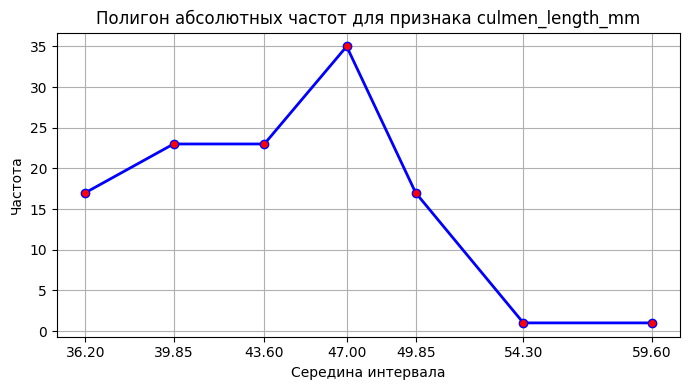

In [ ]:
poligon(cl_x_values, cl_y_values, 'абсолютных', "culmen_length_mm")

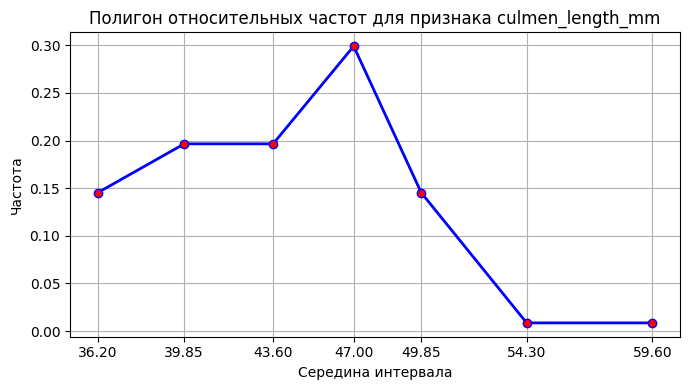

In [ ]:
poligon(cl_x_values, [i/N for i in cl_y_values], 'относительных', "culmen_length_mm")

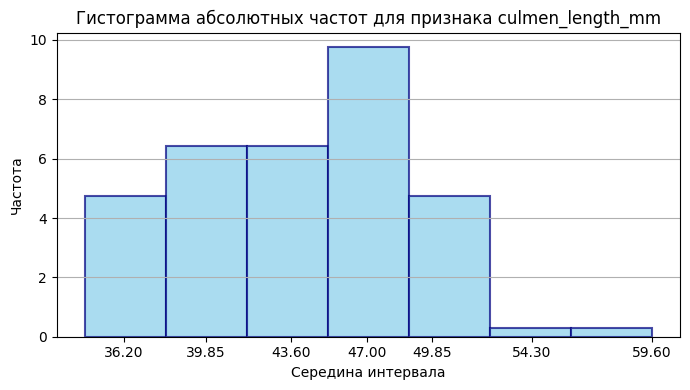

In [ ]:
bar_chart(cl_interval, cl_heights, cl_x_values, cl_h, 'абсолютных', "culmen_length_mm")

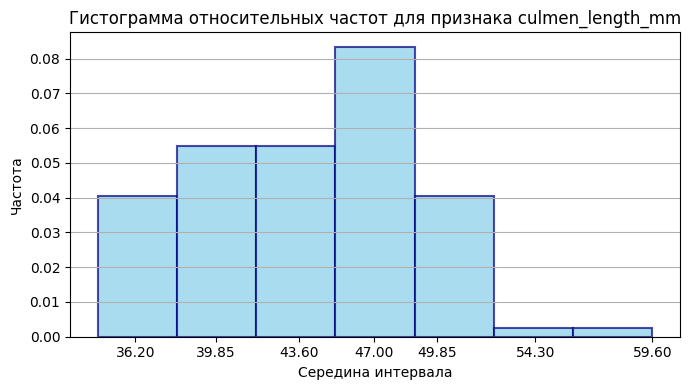

In [ ]:
bar_chart(cl_interval, [i/N for i in cl_heights], cl_x_values, cl_h, 'относительных', "culmen_length_mm")

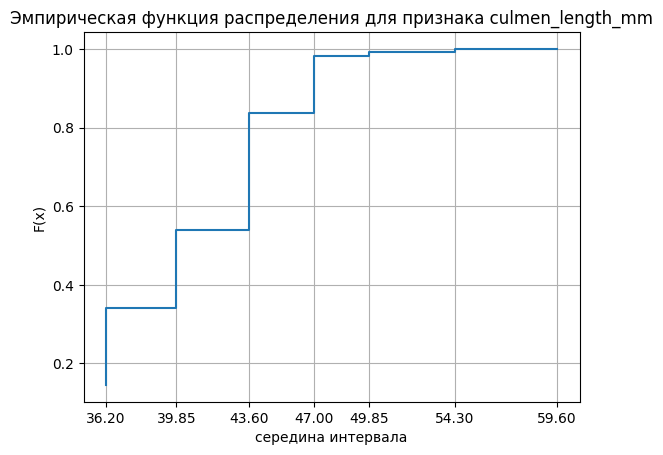

In [ ]:
empirical(cl_x_values, cl_y_values, "culmen_length_mm")

#### На основе полигона, гистограммы и эмпирической функции распределения можно сделать следующие выводы:

Наиболее высокий столбец гистограммы приходится на интервал [45.3, 48.7] с абсолютным значением частоты 35. Далее следует спад до значения 17. Результаты полученные для абсолютных значений пропорциональны получившимся относительным частотам.

На полигоне можно отметить, что количество наблюдений на интервалах с меньшими значениями значительно больше, чем на интервалах с большими значениями, что подтверждает результат отраженный на гистограмме.

Эмпирическая функция распределения F*(x) имеет быстрый рост на участке от 0.14 до примерно 0.98, пологий участок после подтверждает малое число наблюдейний на интервале 49.0 -59.6 мм.



#### Для признака "culmen_depth_mm"

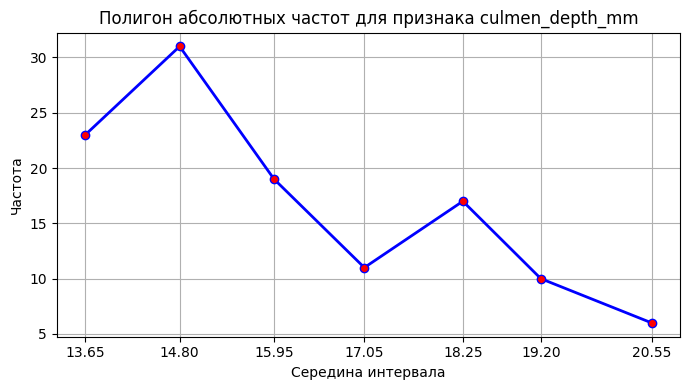

In [ ]:
poligon(cd_x_values, cd_y_values, 'абсолютных', "culmen_depth_mm")

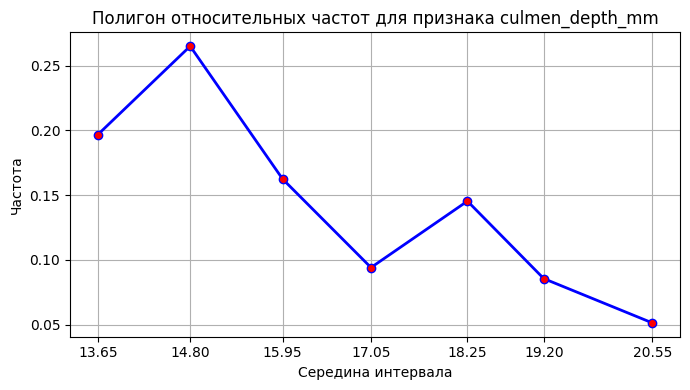

In [ ]:
poligon(cd_x_values, [i/N for i in cd_y_values], 'относительных', "culmen_depth_mm")

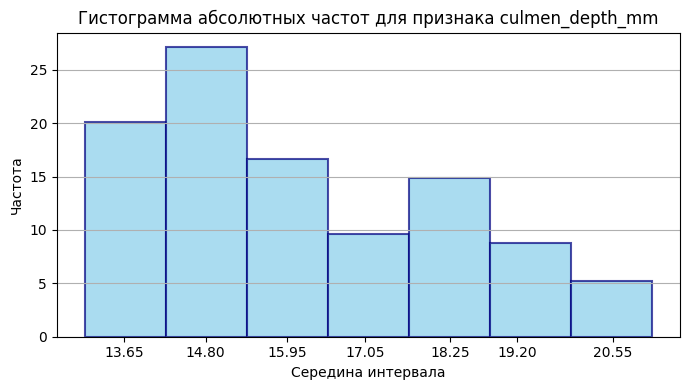

In [ ]:
bar_chart(cd_interval, cd_heights, cd_x_values, cd_h, 'абсолютных', "culmen_depth_mm")

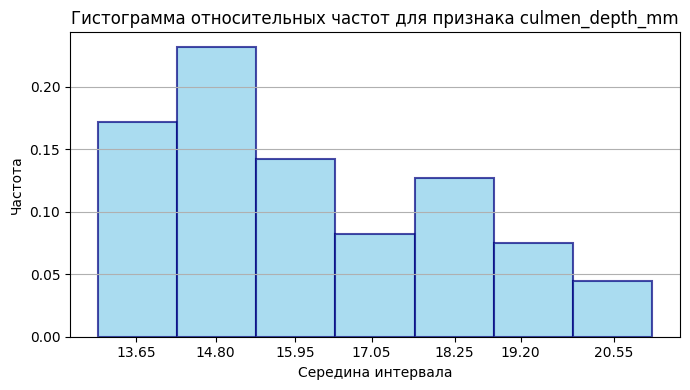

In [ ]:
bar_chart(cd_interval, [i/N for i in cd_heights], cd_x_values, cd_h, 'относительных', "culmen_depth_mm")

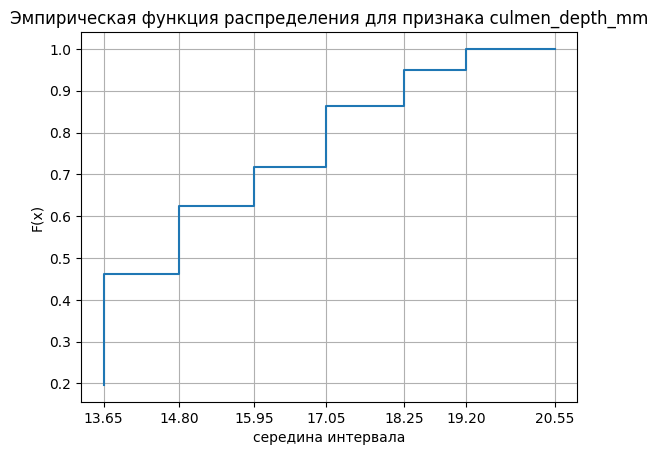

In [ ]:
empirical(cd_x_values, cd_y_values, "culmen_depth_mm")

#### На основе полигона, гистограммы и эмпирической функции распределения можно сделать следующие выводы:

Наиболее высокий столбец гистограммы приходится на интервал [14.3, 15.3] с абсолютным значением частоты 31. Далее следует спад до значения 11 с последующим подъемом до значения абсолютной частоты 17 на интервале [17.7, 18.8]. Результаты полученные для абсолютных значений также пропорциональны получившимся относительным частотам.

На полигоне можно отметить два пика на серединных интервалах 14.8 и 18.25.

Эмпирическая функция распределения F*(x) монотонно растет на всех участках и замедляется на участке 0.95 - 1.


## Выводы

В ходе работы была сформирована выборка объемом 117 наблюдений из генеральной совокупности данных о пингвинах по двум количественным признакам: длина клюва (culmen_length_mm, мм) и высота клюва  (culmen_depth_mm, мм).

Выборка последовательно преобразована в ранжированный, вариационный и интервальный ряды.

По признаку «длина клюва» пик наблюдается в 4-ом интервале [45.3, 48.7]	 с частотой 35.

По признаку «высота клюва» пик наблюдается во 2-ом интервале [14.3, 15.3] с частотой 31.


Построенные гистограммы, полигоны частот и эмпирические функции распределения для абсолютных и относительных частот подтвердили выявленные закономерности.
Графики абсолютных и относительных частот имеют идентичную форму, различаясь лишь масштабом оси ординат. Эмпирическая функция относительных частот определяет для каждого значения x относительную частоту события, что признак примет значение, меньшее заданного x.

Сравнительный анализ обоих признаков указывает на неоднородность выборки, связанную скорее всего с полом особей и с их видовой принадлежностью. В выборке присутствуют два вида пингвинов — Adelie (44 особи) и Gentoo (73 особи), при этом Gentoo в целом крупнее Adelie по обоим измерениям клюва. Распределение длины клюва с пиком в интервале 45.3–48.7 мм (частота 35) и "выбросами" 54.3 и 59.6 мм отражает доминирование более крупного вида Gentoo, а также, вероятно, различия в размерах между самцами и самками внутри вида, где самцы занимают более высокие значения. Глубина клюва также демонстрирует видовые различия: скорее всего Adelie сосредоточены в области меньших значений, а Gentoo — в области больших. Таким образом, наблюдаемые формы распределений обусловлены смешением двух видов с разными размерными характеристиками и половыми различиями внутри них.
